In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go

from rod.helix import Helix
from rod.helix_util import HelixUtil

In [3]:
# Methods to propagate the centerline and material frames of a helix

def propagate_q(q: np.ndarray, r0: np.ndarray, n0: np.ndarray, n_sites: int, s: np.ndarray, r: np.ndarray,
                    n: np.ndarray):
        # Starting with the clamped material frame, integrate forward
        r[0, :] = r0
        n[0, :] = n0
        for i in range(1, n_sites):
            # Left hand side of interval (previous element)
            r_L = r[i - 1]
            n_L = n[i - 1]
            s_R, s_L = s[i], s[i - 1]
            s_sL = s_R - s_L
            # Twist and curvature
            tau, k_1, k_2 = q[3 * i - 3:3 * i]
            # Darboux vector and unit vector aligned with the Darboux vector
            Omega = tau * n_L[0, :] + k_1 * n_L[1, :] + k_2 * n_L[2, :]
            Omega_norm = np.linalg.norm(Omega)

            # Degenerate case: straight line/no change in material frame
            if Omega_norm < 1e-12:
                n[i] = n_L
                r[i] = r_L + n_L[0] * s_sL
                continue

            w = Omega / Omega_norm

            # Projection of vector parallel to and perpendicular to w
            n_L_par = np.dot(n_L, w)[:, np.newaxis] * w
            n_L_perp = n_L - n_L_par

            # Compute the material frame
            n_i = n_L_par + n_L_perp * np.cos(Omega_norm * s_sL) + np.cross(w, n_L_perp) * np.sin(Omega_norm * s_sL)
            n[i] = n_i

            # Compute the centerline
            n_0_parallel = n_L_par[0]
            n_0_perp = n_L_perp[0]
            r_i = (r_L + n_0_parallel * s_sL + n_0_perp * np.sin(Omega_norm * s_sL) / Omega_norm +
                   np.cross(w, n_0_perp) * (1 - np.cos(Omega_norm * s_sL)) / Omega_norm)
            r[i] = r_i
        return r, n

def propagate(helix: Helix) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes the centerline and the material frames from the generalized coordinates [q]

    n_i(s) = n_{i, L}^{Q ||} + n_{i, L}^{Q perp} cos(Omega(s - s_L^Q)) + omega \cross n_{i, L}^{Q perp} sin(Omega(s - s_L^Q))
    """
    # Centerline and material frames
    r = np.zeros((helix.n_sites, 3))
    n = np.zeros((helix.n_sites, 3, 3))
    HelixUtil.propagate_q(helix.q, helix.r0, helix.n0, helix.n_sites, helix.s, r, n)
    return r, n

In [4]:
def plot_helix(r: np.ndarray, n: np.ndarray, ax=None, show_frames=True, frame_step=2, frame_scale=0.02):
    """
    Visualizes the helix centerline and material frames with smaller frames.

    Parameters:
    - r: (n_sites, 3) Centerline positions
    - n: (n_sites, 3, 3) Material frames
    - show_frames: Whether to show material frames
    - frame_step: Step size for plotting frames (to avoid clutter)
    - frame_scale: Scaling factor for material frame vectors
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111, projection='3d')

    # Plot centerline
    ax.plot(r[:, 0], r[:, 1], r[:, 2], 'b-', label="Centerline")

    if show_frames:
        for i in range(0, len(r), frame_step):
            origin = r[i]
            for j, color in enumerate(['r', 'g', 'k']):  # x (red), y (green), z (black)
                frame_vec = n[i, j] * frame_scale  # Scale frame vectors
                ax.quiver(origin[0], origin[1], origin[2], 
                          frame_vec[0], frame_vec[1], frame_vec[2], 
                          color=color, alpha=0.8)
    ax.set_xticks(np.linspace(np.min(r[:, 0]), np.max(r[:, 0]), num=5))  # Adjust for desired number of ticks
    ax.set_yticks(np.linspace(np.min(r[:, 1]), np.max(r[:, 1]), num=5))
    ax.set_zticks(np.linspace(np.min(r[:, 2]), np.max(r[:, 2]), num=5))

    # Fix axis scale to be the same
    ax.set_box_aspect([1, 1, 1])  # Ensure equal scaling for all axes

    # Optionally set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    # ax.set_title('Helix')

    return ax

    # # Labels and view adjustments
    # # ax.set_xlabel('X')
    # # ax.set_ylabel('Y')
    # # ax.set_zlabel('Z')
    # # ax.set_title('Helix')
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.set_zticks([])

    # return ax 

def plot_helix_plotly(helices, show_frames=True, frame_step=2, frame_scale=0.02):
    """
    Creates an interactive visualization of multiple helices' centerlines and material frames.

    Parameters:
    - helices: Array-like of tuples (r, n), where:
      - r: (n_sites, 3) Centerline positions
      - n: (n_sites, 3, 3) Material frames
    - show_frames: Whether to show material frames
    - frame_step: Step size for plotting frames (to avoid clutter)
    - frame_scale: Scaling factor for material frame vectors
    """
    # Create figure
    fig = go.Figure()

    # Plot each helix
    for idx, (r, n) in enumerate(helices):
        # Plot centerline
        fig.add_trace(go.Scatter3d(
            x=r[:, 0], y=r[:, 1], z=r[:, 2],
            mode='lines',
            line=dict(width=3),
            name=f'Centerline {idx + 1}'
        ))

        # Plot material frames as arrows
        if show_frames:
            for i in range(0, len(r), frame_step):
                origin = r[i]
                for j, color in enumerate(['red', 'green', 'black']):  # x (red), y (green), z (black)
                    frame_vec = n[i, j] * frame_scale  # Scale frame vectors
                    fig.add_trace(go.Scatter3d(
                        x=[origin[0], origin[0] + frame_vec[0]],
                        y=[origin[1], origin[1] + frame_vec[1]],
                        z=[origin[2], origin[2] + frame_vec[2]],
                        mode='lines',
                        line=dict(color=color, width=2),
                        showlegend=False  # Avoid excessive legend entries
                    ))

    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
        ),
        title=dict(text='Helix Visualization', y=0.95, x=0.5, xanchor='center', yanchor='top'),
    )

    fig.show()

(50, 3)


<Axes3DSubplot:xlabel='X', ylabel='Y'>

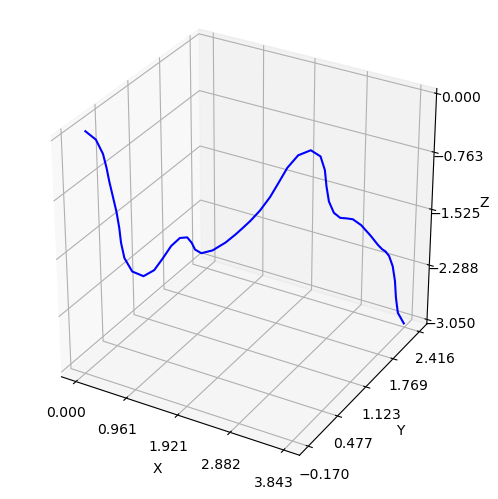

In [5]:
# Instantiating and Integrating Centerline + Material Frames for 1 Helical Segment

n_sites = 50  # Number of sites along the helix
L = 10.0  # Total length
s = np.linspace(0, L, n_sites)  # Arc length array

# Initial position: Start the curl at the origin
r0 = np.array([0.0, 0.0, 0.0])

# Initial material frame: Oriented along the curl
n0 = np.eye(3)  # Standard basis (modify if needed)

# Create a twisting and bending motion in q
twist = np.full(n_sites, np.pi / 4)
# twist = np.zeros(n_sites)
curvature_x = 3.0 * np.cos(s * np.pi) + np.random.random_sample() # Varies to form a curl
curvature_y = 0 #3.0 * np.sin(s * np.pi) + np.random.random_sample()  # Varies to form a curl

q = np.zeros((3 * n_sites,))
q[0::3] = twist
q[1::3] = curvature_x
q[2::3] = curvature_y

# Define stiffness (optional)
EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness

# Create helix instance
# r0 and n0 are the position and material frame of the clamped top node
helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)

# Perform one propagation step
r, n = propagate(helix_instance)

# print("Propagated centerline positions:\n", r)
# print("Propagated material frames:\n", n)

# Generate and propagate a helix (from previous code)
r, n = HelixUtil.propagate(helix_instance)
print(r.shape)

# Plot the helix with small material frames
plot_helix_plotly([(r, n)], frame_scale=0.2, show_frames=True)
plot_helix(r, n, show_frames=False, frame_scale=0.2)

[0.01   0.2575 0.505  0.7525 1.    ]
[0.    0.375 0.75  1.125 1.5  ]
0.0 0.0
0.0 0.9001127896610162
0.0 0.46805688586970495
0.0 0.3161983836441228
0.0 0.238732414637843
3.883495145631068 0.0
3.883495145631068 0.9001127896610162
3.883495145631068 0.46805688586970495
3.883495145631068 0.3161983836441228
3.883495145631068 0.238732414637843
1.9801980198019802 0.0
1.9801980198019802 0.9001127896610162
1.9801980198019802 0.46805688586970495
1.9801980198019802 0.3161983836441228
1.9801980198019802 0.238732414637843
1.3289036544850499 0.0
1.3289036544850499 0.9001127896610162
1.3289036544850499 0.46805688586970495
1.3289036544850499 0.3161983836441228
1.3289036544850499 0.238732414637843
1.0 0.0
1.0 0.9001127896610162
1.0 0.46805688586970495
1.0 0.3161983836441228
1.0 0.238732414637843


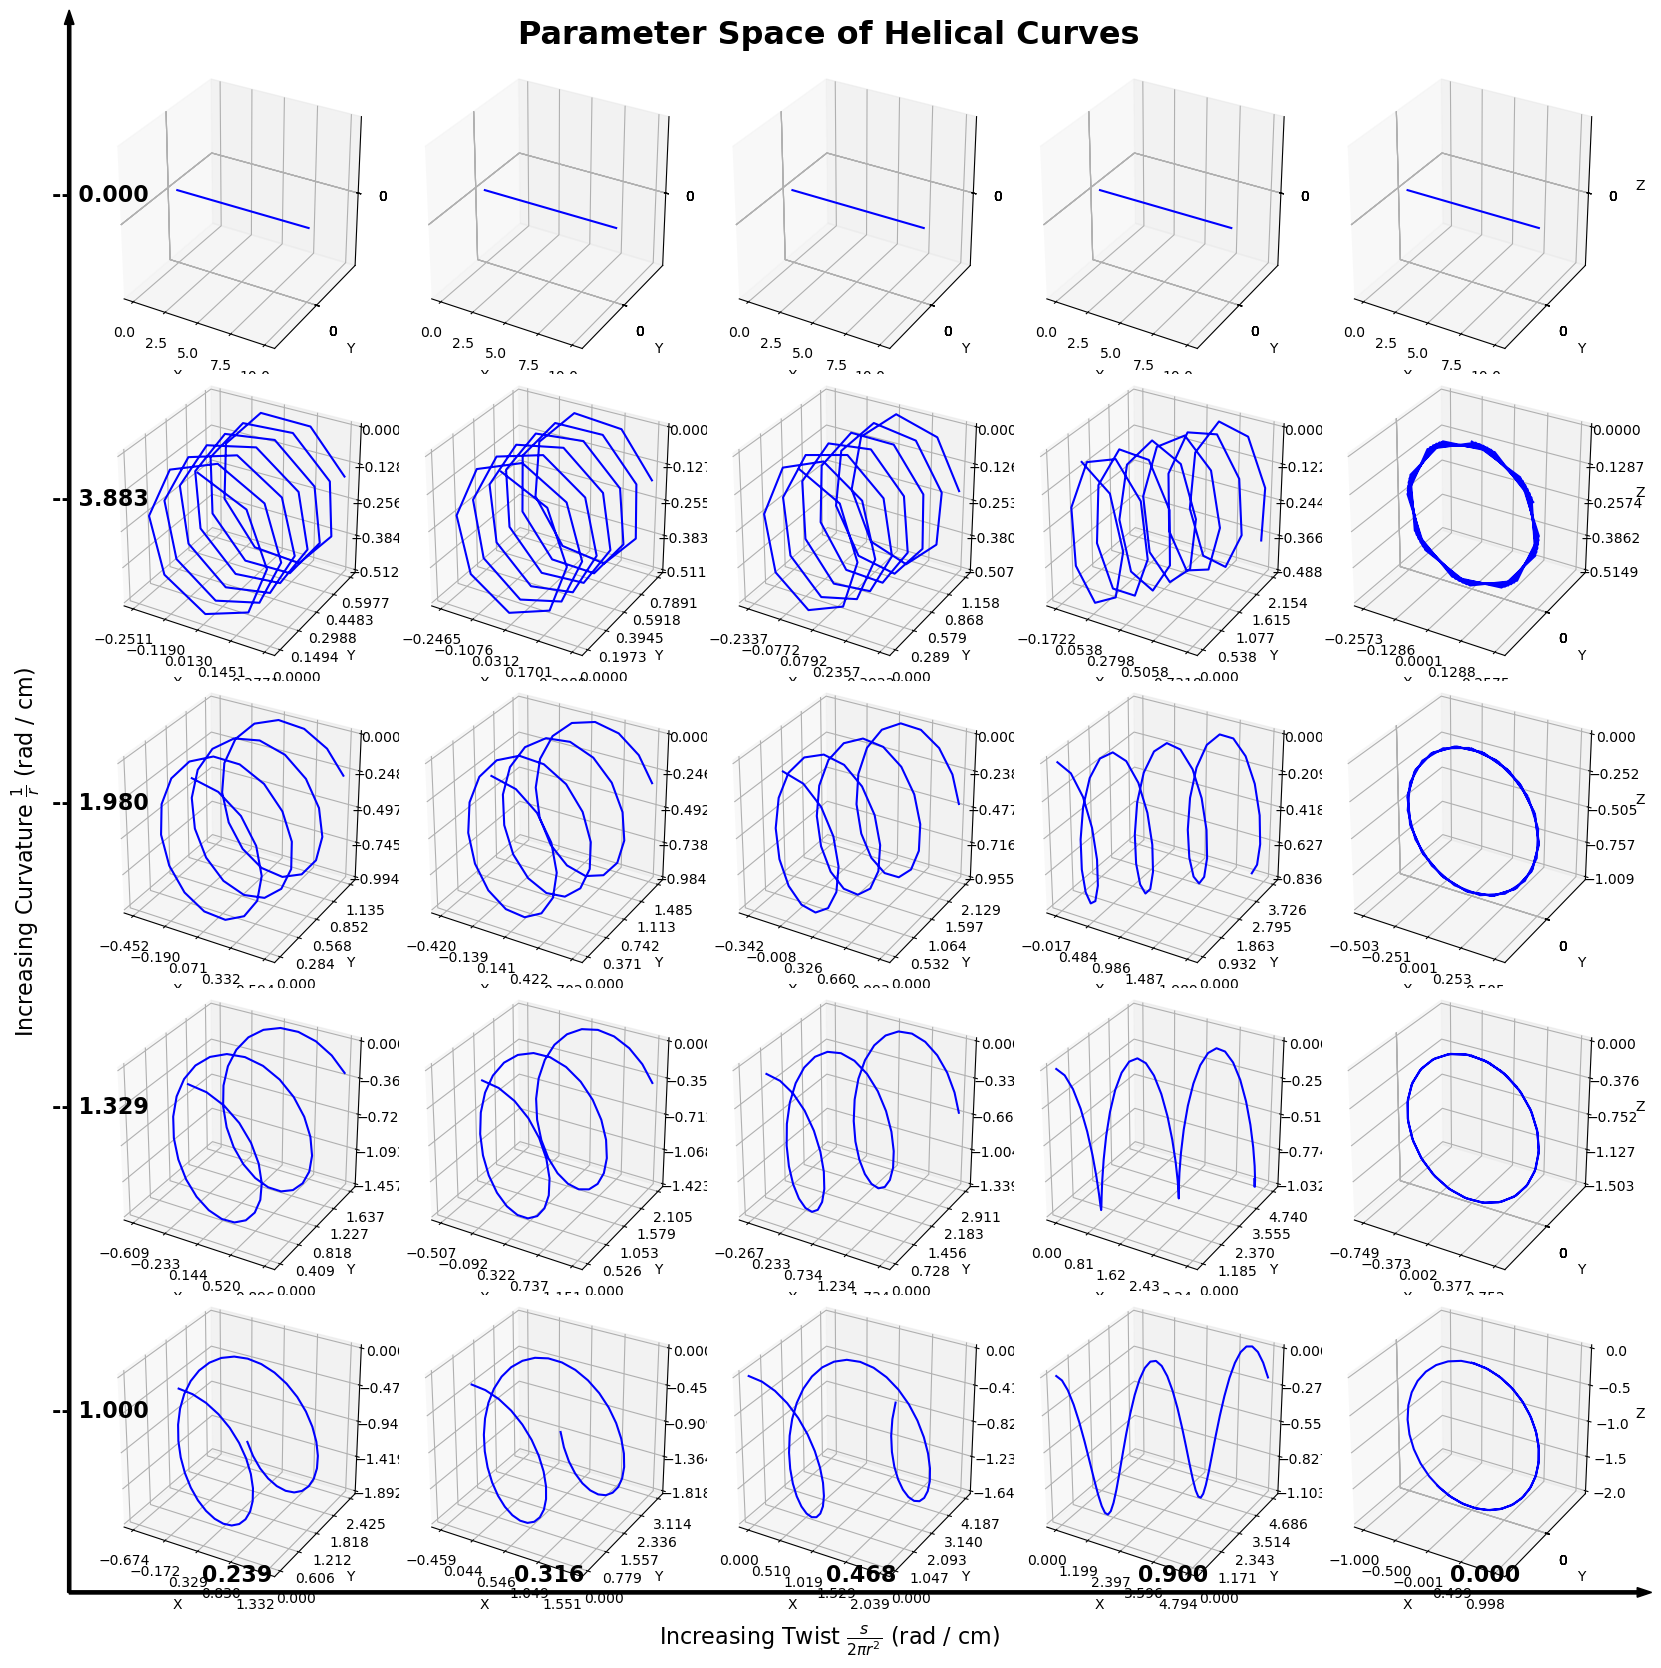

In [6]:
# Defining curvature & twist from natural hair parameters
# k1 = 1 / hair_radius
# k2 = 0
# twist = (helix_step) / 2 * pi * hair_radius^2
hair_radius = np.linspace(0.01, 1, 5) # micrometers
helix_step = np.linspace(0, 1.5, 5) # micrometers
print(hair_radius)
print(helix_step)

k1_values = 1 / hair_radius
k1_values[0] = 0 # divide by 0
k2_values = np.zeros_like(k1_values)
twist_values = (helix_step) / (2 * np.pi * hair_radius**2)
twist_values[0] = 0

n_sites = 50
L = 10.0
s = np.linspace(0, L, n_sites) 
r0 = np.array([0, 0, 0])
n0 = np.eye(3)

fig, axes = plt.subplots(5, 5, figsize=(16, 16), subplot_kw={'projection': '3d'})
for i, k1 in enumerate(k1_values):
    for j, twist in enumerate(twist_values):
        print (k1, twist)
        q = np.zeros((3 * n_sites,))
        q[0::3] = twist
        q[1::3] = k1  # Assign curvature_x
        q[2::3] = 0   # Zero curvature_y

        EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness

        # Create and propagate the helix
        helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)
        r, n = HelixUtil.propagate(helix_instance)

        # Plot in the corresponding subplot
        ax = axes[i, 4-j]
        #print(i, 4-j)
        plot_helix(r, n, show_frames=False, frame_scale=0.2, ax=ax)
        # ax.set_title(f"k_1={k1:.3f}, Twist={twist:.3f}")

fig.supxlabel(r"Increasing Twist $\frac{s}{2\pi r^2}$ (rad / cm)", y=-0.004, fontsize=16)
fig.supylabel(r"Increasing Curvature $\frac{1}{r}$ (rad / cm)", x=-0.012, fontsize=16) #"Increasing Twist $\frac{s}{2\pi r^2}$"
fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
arrow_x = patches.FancyArrow(0.025, 0.037, 0.98, 0, width=0.002, transform=fig.transFigure, color='black')
arrow_y = patches.FancyArrow(0.025, 0.037, 0, 0.98, width=0.002, transform=fig.transFigure, color='black')
fig.patches.extend([arrow_x, arrow_y])

for i, k1 in enumerate(k1_values):
    fig.text(0.075, 0.15 + 0.19 * (4-i), f"-- {k1:.3f}", fontsize=16, fontweight='bold', transform=fig.transFigure, ha="right", va="center")

for j, twist in enumerate(twist_values):
    fig.text(0.13 + 0.195 * (4-j), 0.055, f"{twist:.3f}", fontsize=16, fontweight='bold', transform=fig.transFigure, ha="center", va="top")

plt.tight_layout()
plt.suptitle("Parameter Space of Helical Curves", fontsize=23, fontweight='bold', y=1.02)
plt.show()

In [7]:
import plotly.graph_objects as go

def plot_helix_plotly(helices, show_frames=True, frame_step=2, frame_scale=0.02):
    """
    Creates an interactive visualization of multiple helices' centerlines and material frames.

    Parameters:
    - helices: Array-like of tuples (r, n), where:
      - r: (n_sites, 3) Centerline positions
      - n: (n_sites, 3, 3) Material frames
    - show_frames: Whether to show material frames
    - frame_step: Step size for plotting frames (to avoid clutter)
    - frame_scale: Scaling factor for material frame vectors
    """
    # Create figure
    fig = go.Figure()

    # Plot each helix
    for idx, (r, n) in enumerate(helices):
        # Plot centerline
        fig.add_trace(go.Scatter3d(
            x=r[:, 0], y=r[:, 1], z=r[:, 2],
            mode='lines',
            line=dict(width=3),
            name=f'Centerline {idx + 1}'
        ))

        # Plot material frames as arrows
        if show_frames:
            for i in range(0, len(r), frame_step):
                origin = r[i]
                for j, color in enumerate(['red', 'green', 'black']):  # x (red), y (green), z (black)
                    frame_vec = n[i, j] * frame_scale  # Scale frame vectors
                    fig.add_trace(go.Scatter3d(
                        x=[origin[0], origin[0] + frame_vec[0]],
                        y=[origin[1], origin[1] + frame_vec[1]],
                        z=[origin[2], origin[2] + frame_vec[2]],
                        mode='lines',
                        line=dict(color=color, width=2),
                        showlegend=False  # Avoid excessive legend entries
                    ))

    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
        ),
        title=dict(text='Helix Visualization', y=0.95, x=0.5, xanchor='center', yanchor='top'),
    )

    fig.show()


In [8]:
# Generating many helices with specific starting points
scalp_pos = np.load("scalp_pos.npy") # positions of each follicle, n_points per follicles, 3
print(scalp_pos.shape)
scalp_pos_small = scalp_pos[:, ::5, :]

# Toy values
twist = np.full(n_sites, np.pi / 6) 
n_sites = 50
curvature_x = np.full(n_sites, 0.05)
# curvature_y = np.full(n_sites, 0.05)

r_ns = []

for i in range(scalp_pos_small.shape[0]):
    # for j in range(scalp_pos_small.shape[1]):
    j = np.random.randint(scalp_pos_small.shape[1])
    r0 = scalp_pos_small[i, j, :]
    n0 = np.eye(3)
    q = np.zeros((3 * n_sites,))
    q[0::3] = twist * np.random.random_sample()
    q[1::3] = curvature_x * np.random.random_sample()
    q[2::3] = 0
    EI = np.ones((3 * n_sites,)) * 0.1  # Uniform stiffness

    # Create and propagate the helix
    helix_instance = Helix(q=q, q0=q, n_sites=n_sites, s=s, L=L, r0=r0, n0=n0, EI=EI)
    r, n = HelixUtil.propagate(helix_instance)
    r_ns.append((r, n))

plot_helix_plotly(r_ns, show_frames=False, frame_scale=0.2)

(200, 128, 3)


## Scalp Generation

In [9]:
import pickle

with open("evolved_helices_0510.pkl", "rb") as f:
    evolved_helices = pickle.load(f)

helix_params = []
for helix in evolved_helices[:200]:
    r, n = HelixUtil.propagate(helix)
    helix_params.append((r, n))

plot_helix_plotly(helix_params, show_frames=False, frame_scale=0.2)

In [15]:
with open("evolved_helices.pkl", "rb") as f:
    evolved_helices = pickle.load(f)

helix_params = []
for helix in evolved_helices[:200]:
    r, n = HelixUtil.propagate(helix)
    helix_params.append((r, n))

plot_helix_plotly(helix_params, show_frames=False, frame_scale=0.2)

In [12]:
# Concatenating two segments, using the centerline position and material frame of 
# the last site of the first segment as the starting point for the second segment

helix1 = helix_instance

n2_sites = 200
L2 = 5.0  # Total length
s2 = np.linspace(0, L2, n2_sites)  # Arc length array
r20 = r[-1]
n20 = np.eye(3)  # Standard basis (modify if needed)
twist2 = np.full(n2_sites, np.pi / 2)   # No initial twist
curvature_x2 = 4.0 * np.cos(s2 * np.pi)  # Varies to form a curl
curvature_y2 = 4.0 * np.sin(s2 * np.pi)  # Varies to form a curl

q2 = np.zeros((3 * n2_sites,))
q2[0::3] = twist2
q2[1::3] = curvature_x2
q2[2::3] = curvature_y2

EI2 = np.ones((3 * n2_sites,)) * 0.1  # Uniform stiffness

helix2 = Helix(q=q2, q0=q2, n_sites=n2_sites, s=s2, L=L2, r0=r20, n0=n20, EI=EI2)

r2, n2 = HelixUtil.propagate(helix2)

plot_helix_plotly([(r, n), (r2, n2)], frame_scale=0.2, show_frames=False)